# House Prices Regression Task - week 2

I chose the dataset House Prices. Previously, I have already built a model for detecting heart disease. I don't have much proficiency with NLP and working with text, which is why I also didn't choose SMS spam collection. Titanic seemed to me familiar. 

## Import the required libraries and dataset

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("done")

done


In [2]:
df = pd.read_csv('Housing.csv', index_col=0)

In [3]:
df

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,
13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished


## EDA - Exploratory Data Analysis

In [4]:
df.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,
13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
df.tail()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
price,,,,,,,,,,,,
1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [6]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

Obviously, the target variable is price, while other variables - features for predicting the target variable. The price is as index, so use _resetindex_

In [7]:
df.shape

(545, 12)

The dataset has 545 rows and 12 columns 

In [8]:
df.dtypes

area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

The dataset has 5 numerical columns and 7 categorical columns. Numerical columns will need to be scaled while categorical columns definitely need to be encoded. The ultimate goal is to predict as closely as possible the prices of houses. 

In [9]:
df.isnull().sum()

area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Great, no missing values, now no need to deal with it. Let's see how many duplicates it has

In [10]:
df.duplicated().sum()

6

I will drop the duplicated rows

In [11]:
df = df.drop_duplicates()

In [12]:
num_col = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
cat_col = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 539 entries, 13300000 to 1750000
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   area              539 non-null    int64 
 1   bedrooms          539 non-null    int64 
 2   bathrooms         539 non-null    int64 
 3   stories           539 non-null    int64 
 4   mainroad          539 non-null    object
 5   guestroom         539 non-null    object
 6   basement          539 non-null    object
 7   hotwaterheating   539 non-null    object
 8   airconditioning   539 non-null    object
 9   parking           539 non-null    int64 
 10  prefarea          539 non-null    object
 11  furnishingstatus  539 non-null    object
dtypes: int64(5), object(7)
memory usage: 54.7+ KB


Take a look at these categorical columns

All categorical columns - except _furnishingstatus_ have only two labels Yes/No while _furnishingstatus_ has 3 labels

In [14]:
df['furnishingstatus'].value_counts()

furnishingstatus
semi-furnished    227
unfurnished       174
furnished         138
Name: count, dtype: int64

To see closer the categorical columns, I will draw bar plots - to better visuzalize the distribution of yes/no values in these columns. Currently, if too look at percentage of labels, the following numbers are obtained. 

In [15]:
for x in cat_col:
    print(df[x].value_counts() / 539)

mainroad
yes    0.857143
no     0.142857
Name: count, dtype: float64
guestroom
no     0.820037
yes    0.179963
Name: count, dtype: float64
basement
no     0.647495
yes    0.352505
Name: count, dtype: float64
hotwaterheating
no     0.953618
yes    0.046382
Name: count, dtype: float64
airconditioning
no     0.680891
yes    0.319109
Name: count, dtype: float64
prefarea
no     0.766234
yes    0.233766
Name: count, dtype: float64
furnishingstatus
semi-furnished    0.42115
unfurnished       0.32282
furnished         0.25603
Name: count, dtype: float64


## Visuzalizations

In [16]:
import matplotlib.pyplot as plt

### Barplots

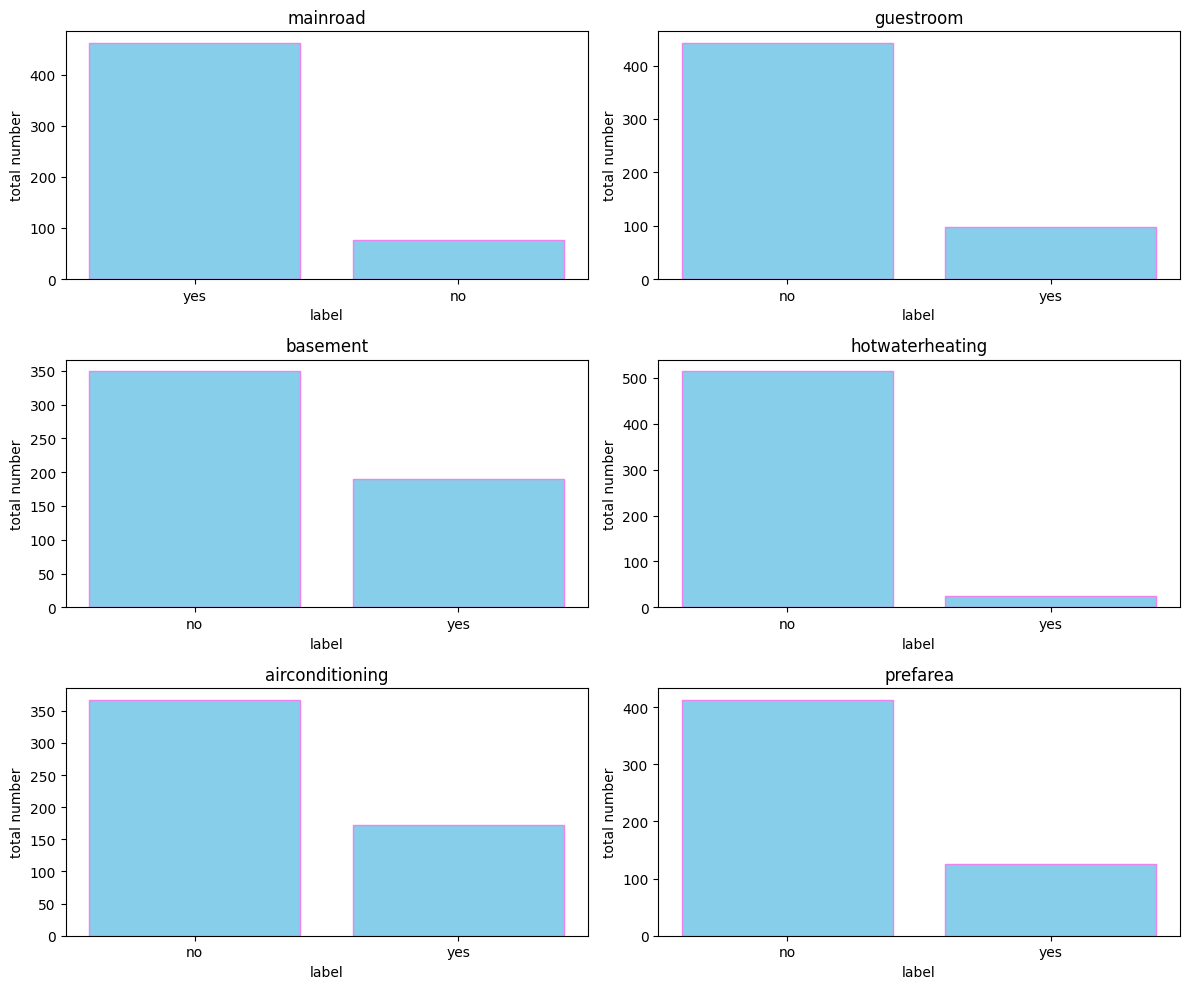

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), cat_col):
    data = df[col].value_counts()
    
    ax.bar(data.index, data.values, color='skyblue', edgecolor='violet')
    ax.set_title(col)
    ax.set_xlabel('label')
    ax.set_ylabel('total number')

plt.tight_layout()
plt.show()

In [18]:
df[num_col].describe()

,area,bedrooms,bathrooms,stories,parking
count,539.000000,539.000000,539.000000,539.000000,539.000000
mean,5171.103896,2.970315,1.289425,1.807050,0.701299
std,2171.610469,0.738638,0.504349,0.868633,0.863241
min,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3600.000000,2.500000,1.000000,1.000000,0.000000
50%,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,6380.000000,3.000000,2.000000,2.000000,1.000000
max,16200.000000,6.000000,4.000000,4.000000,3.000000


### The analysis of describe function
This will help me with discovering features with skewed data. This information in turn can indicate how to fill missing values though in this dataset there is no missing values. The features with skewed data in turn to get visuzalition to see closer the non-uniform distribution. It also helps me to discover outliers. 

Let's look closely at stats of numerical columns and details:

- area: mean = 5150, 50% (median) = 4600. Since mean > median => right skewed data. Also, notice this: max = 16500 while 75% = 6360, big difference. Draw histogram to confirm. 
- bedrooms: mean = 3 almost, median = 3, min is 1 and max is 6, seems fair and good, I don't think it is skewed and probably won't draw distribution for this
- bathrooms: mean = 1.29 and median = 1, maybe a skew, since it says most houses have 1 bathroom and smaller number has bigger number -> maybe skewed
- stories: mean = 2 and median = 2, min = 1 and max = 4, seems okay, no skewed data
- parking: mean = 0.69 and median = 0. Median of 0 indicates at least half of the houses have no parking space, while mean indicates some houses have more spaces => can be skewed. mean > median => right skewed data.

So, to confirm my theory about skewed _area, bathrooms, parking_ and also as additionaly i can also draw for others to confirm of course always. 

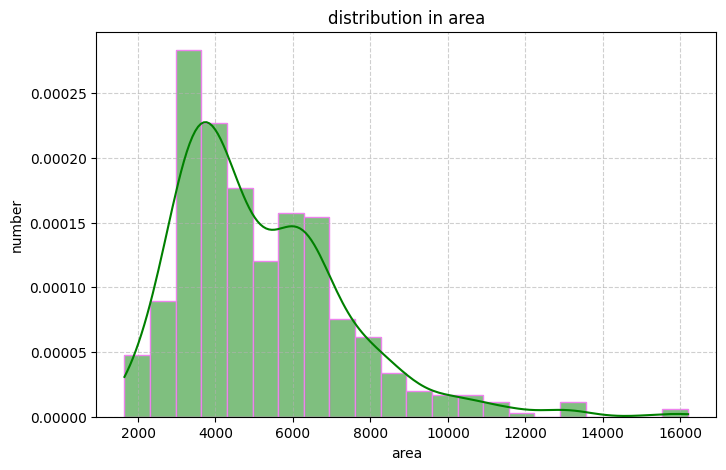

In [19]:
data = df['area']
plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, stat="density", color='green', edgecolor='violet')
plt.title("distribution in area")
plt.xlabel('area')
plt.ylabel('number')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Barplots for numerical columns 

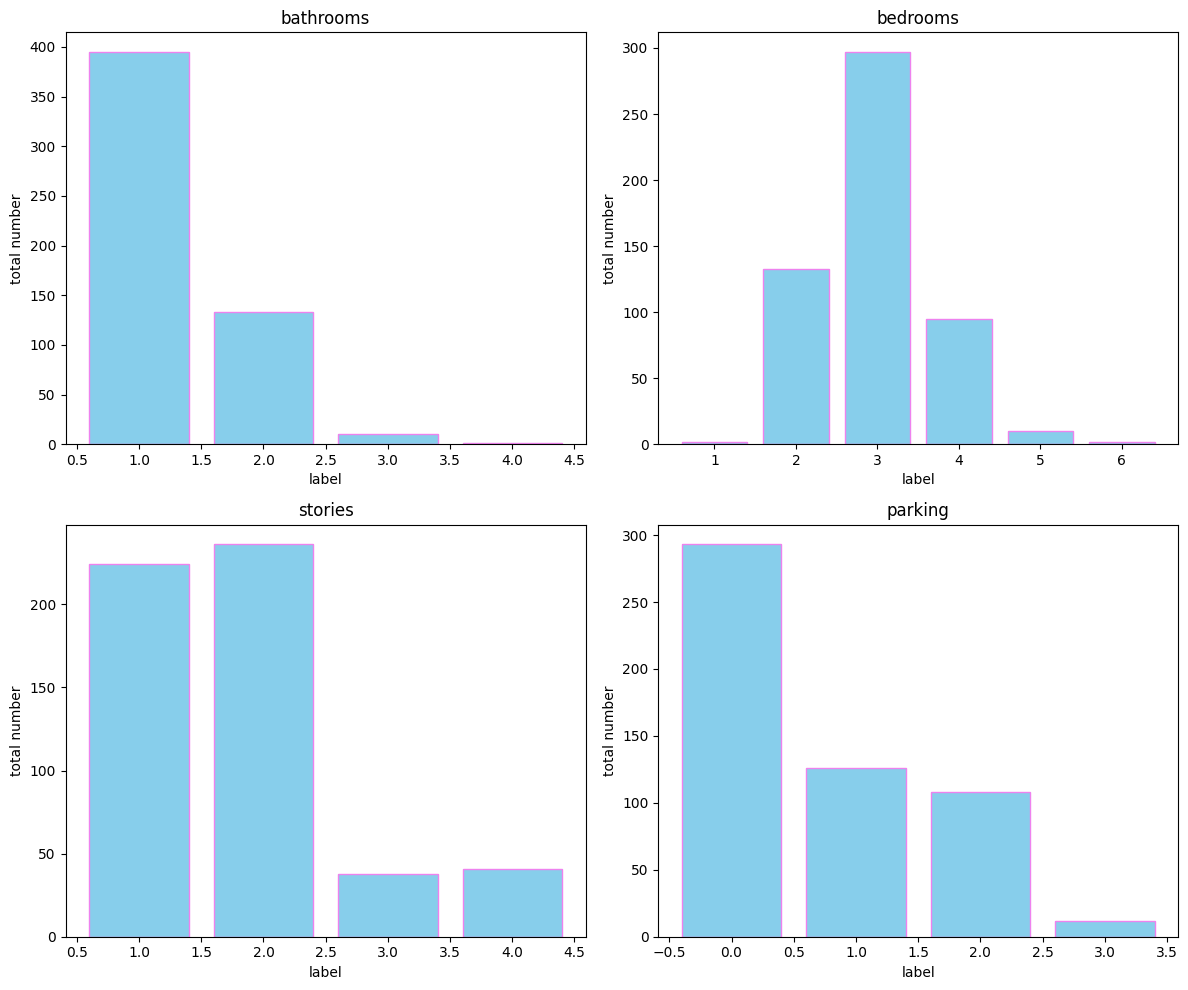

In [20]:
num_cat1 = ['bathrooms', 'bedrooms', 'stories', 'parking']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, col in zip(axes.flatten(), num_cat1):
    data = df[col].value_counts()
    
    ax.bar(data.index, data.values, color='skyblue', edgecolor='violet')
    ax.set_title(col)
    ax.set_xlabel('label')
    ax.set_ylabel('total number')

plt.tight_layout()
plt.show()

What can already be inferred, the outliers are present. Let's see them closer by drawing whisker plots. 

### Whisker plot

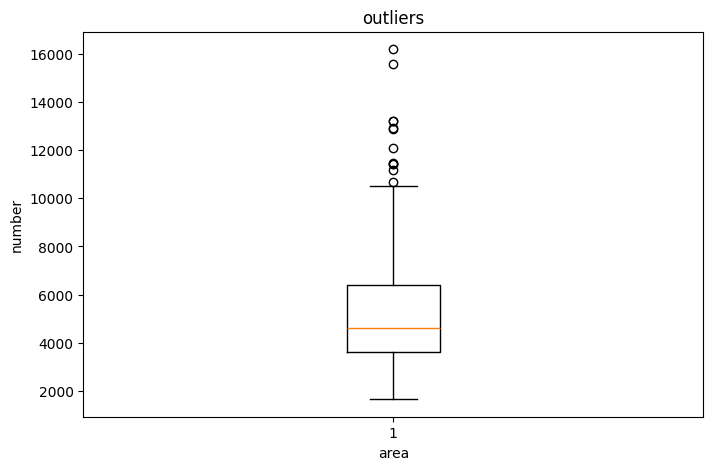

In [21]:
data = df['area']
plt.figure(figsize=(8, 5))
plt.boxplot(data)
plt.title("outliers")
plt.xlabel('area')
plt.ylabel('number')
plt.show()

Text(0, 0.5, 'parking')

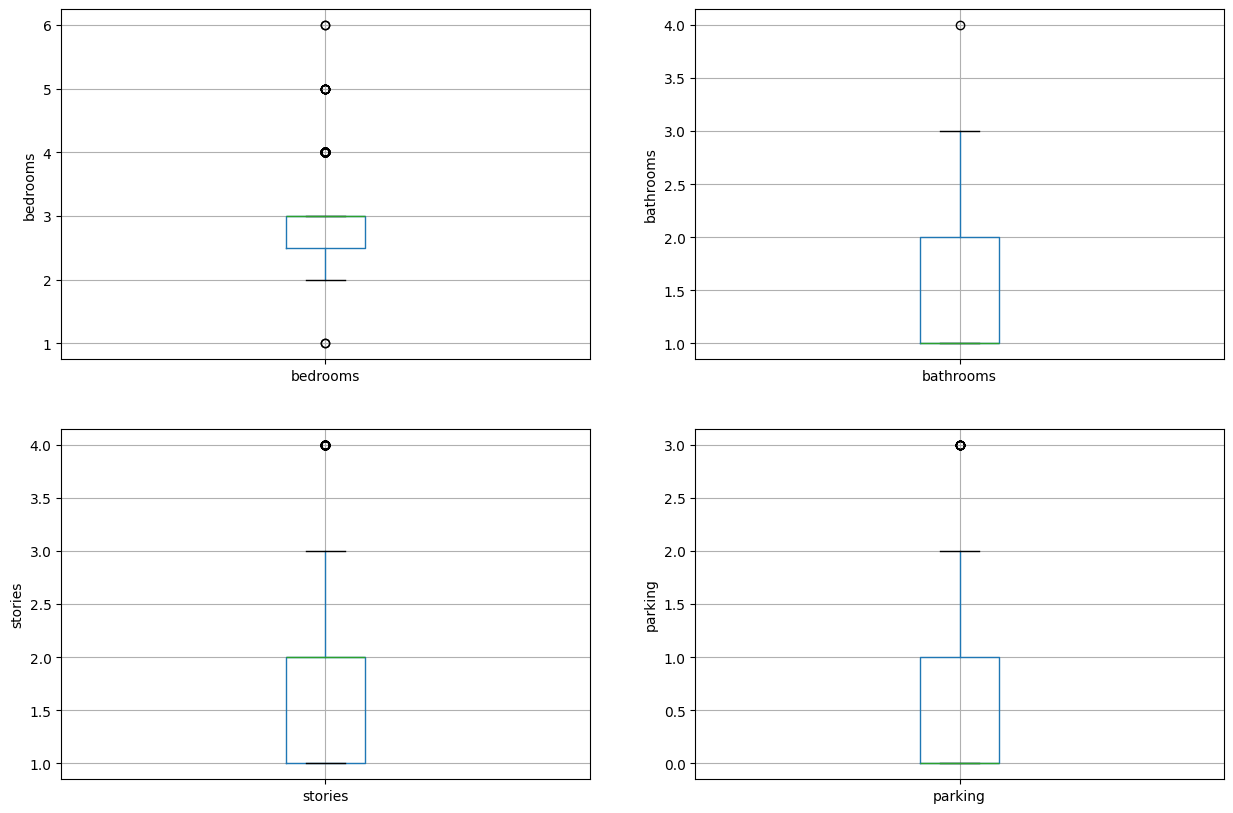

In [22]:
plt.figure(figsize=(15,10))


plt.subplot(2, 2, 1)
fig = df.boxplot(column='bedrooms')
fig.set_title('')
fig.set_ylabel('bedrooms')


plt.subplot(2, 2, 2)
fig = df.boxplot(column='bathrooms')
fig.set_title('')
fig.set_ylabel('bathrooms')


plt.subplot(2, 2, 3)
fig = df.boxplot(column='stories')
fig.set_title('')
fig.set_ylabel('stories')


plt.subplot(2, 2, 4)
fig = df.boxplot(column='parking')
fig.set_title('')
fig.set_ylabel('parking')

### IQR to find maximum values
I will later use this information to remove outliers

In [23]:
for x in num_cat1:
    print(df[x].value_counts())

bathrooms
1    395
2    133
3     10
4      1
Name: count, dtype: int64
bedrooms
3    297
2    133
4     95
5     10
6      2
1      2
Name: count, dtype: int64
stories
2    236
1    224
4     41
3     38
Name: count, dtype: int64
parking
0    293
1    126
2    108
3     12
Name: count, dtype: int64


There are some numbers labels that appear only once or twice in the entire column. 
Find exact max value for area

In [24]:
IQR = df.area.quantile(0.75) - df.area.quantile(0.25)
Lower_fence = df.area.quantile(0.25) - (IQR * 3)
Upper_fence = df.area.quantile(0.75) + (IQR * 3)
print('Area outliers are values < {lowerboundary} or > {upperboundary}'.format(lowerboundary=Lower_fence, upperboundary=Upper_fence))

Area outliers are values < -4740.0 or > 14720.0


Thus, the maximum value for area will be 14720, for bedrooms = 4, bathrooms = 2, parking = 2

### Scatter plot for relationship between area and price

In [25]:
df = df.reset_index()

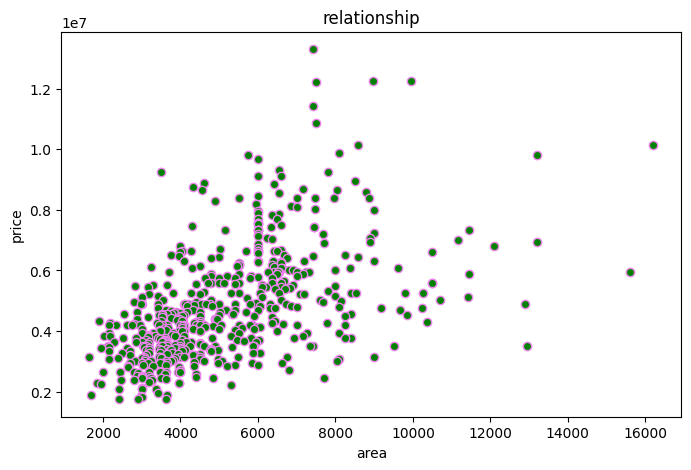

In [26]:
x = df['area']
y = df['price']

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='green', edgecolor='violet')
plt.title("relationship")
plt.xlabel('area')
plt.ylabel('price')
plt.show()

### Heatmap - correlation between variables and target variable

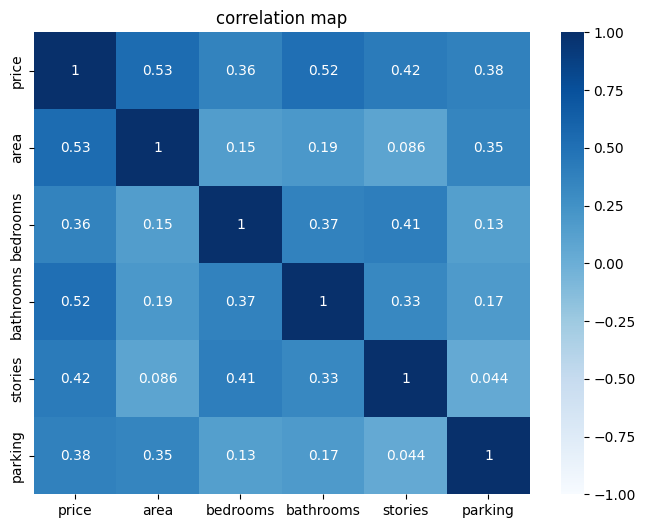

In [27]:
num_col1 = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
df1 = df[num_col1]
corr1 = df1.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr1, annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('correlation map')
plt.show()

### Here, I think I am done with EDA, here is what I have gathered so far:

- there is no multicollinearity, the correlation between variables isn't very big - no need to delete some feature/column. In case of multicollinearity, further actions would be needed
- area is skewed -> I initially used RobustScaler, but when I applied log transformation and then used Standard Scaler, the performance metric has improved. Since the area is usually very skewed feature, it is better as I realized to apply transformations. Why log transformation? To handle right-skewed data of feature area 
- No null values
- I will more closely look at feature importance by running RandomForest at the end - I also plan to modify if needed, experiment, and compare resulting performances 

## Split the data 

### Once I split the data, what I plan to do:
- split data
- feature engineering - has_parking instead of how many parking bcs mostly there was skewed data mean > meadian, most didn't have parking so to fix that I can do this feature engineering, just add it instead of deleting previous stuff
- encoding categorical columns (yes/no - just do mapping, furnishingstatus - one-hot encoding bcs i don't think it depends on it some preferably will choose unfinished to decorate it themselves)
- scaling 
- remove outliers from area IQR
- models to train - Linear regression, RandomForest, XGBoost (not too big dataset bcs LightGBM can be prone to overfitting for smaller datasets) + hyperparameter tuning (GridSearchCV, cv=5)
- feature importance - remove some column if needed and check how it influences
- compare metrics - MAE performance 

### Split the dataset

In [28]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [29]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
534,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
535,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
536,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
537,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished


In [30]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
534     1855000
535     1820000
536     1767150
537     1750000
538     1750000
Name: price, Length: 539, dtype: int64

### Feature engineering

In [31]:
X_train['has_parking'] = (X_train['parking'] > 0).astype(int)
X_test['has_parking'] = (X_test['parking'] > 0).astype(int)

### Encoding categorical columns

In [32]:
cat_col_no_furnis = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for x in cat_col_no_furnis:
    X_train[x] = (X_train[x] == 'yes').astype(int)
    X_test[x] = (X_test[x] == 'yes').astype(int)


In [33]:
from sklearn.preprocessing import OneHotEncoder

ht = OneHotEncoder(sparse_output = False)
x_train_ht = ht.fit_transform(X_train[['furnishingstatus']])
x_test_ht = ht.transform(X_test[['furnishingstatus']])

cols = ht.get_feature_names_out(['furnishingstatus'])
x_train_ht_df = pd.DataFrame(x_train_ht, columns=cols, index=X_train.index)
x_test_ht_df = pd.DataFrame(x_test_ht, columns=cols, index=X_test.index)

### Scaling numerical columns
1. Remove outliers
2. Apply log transformation
3. Do StandardScaler

In [34]:
def max_value(df3, variable, top):
    return np.where(df3[variable]>top, top, df3[variable])

for df3 in [X_train, X_test]:
    df3['area'] = max_value(df3, 'area', 14720)
    df3['bedrooms'] = max_value(df3, 'bedrooms', 4)
    df3['bathrooms'] = max_value(df3, 'bathrooms', 2)
    df3['parking'] = max_value(df3, 'parking', 2)

In [35]:
X_train.area.max(), X_test.area.max()

(14720, 13200)

In [36]:
X_train.bedrooms.max(), X_test.bedrooms.max()

(4, 4)

In [37]:
X_train.bathrooms.max(), X_test.bathrooms.max()

(2, 2)

In [38]:
X_train.parking.max(), X_test.parking.max()

(2, 2)

In [39]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler
trf = FunctionTransformer(func=np.log1p)

X_train_transformed = trf.fit_transform(X_train[['area']]) 
X_test_transformed = trf.transform(X_test[['area']])

sc = StandardScaler()

x_train_sc = sc.fit_transform(X_train_transformed)
x_test_sc = sc.transform(X_test_transformed)

x_train_sc_df = pd.DataFrame(
    x_train_sc,
    columns=['area'],
    index=X_train.index
)

x_test_sc_df = pd.DataFrame(
    x_test_sc,
    columns=['area'],
    index=X_test.index
)

In [40]:
# bedrooms
x_train_bd = sc.fit_transform(X_train[['bedrooms']])
x_test_bd = sc.transform(X_test[['bedrooms']])

cols = sc.get_feature_names_out(['bedrooms'])
x_train_bd_df = pd.DataFrame(x_train_bd, columns=[cols], index=X_train.index)
x_test_bd_df = pd.DataFrame(x_test_bd, columns=[cols], index=X_test.index)

# stories
x_train_st = sc.fit_transform(X_train[['stories']])
x_test_st = sc.transform(X_test[['stories']])

cols = sc.get_feature_names_out(['stories'])
x_train_st_df = pd.DataFrame(x_train_st, columns=[cols], index=X_train.index)
x_test_st_df = pd.DataFrame(x_test_st, columns=[cols], index=X_test.index)

# bathrooms
x_train_bt = sc.fit_transform(X_train[['bathrooms']])
x_test_bt = sc.transform(X_test[['bathrooms']])

cols = sc.get_feature_names_out(['bathrooms'])
x_train_bt_df = pd.DataFrame(x_train_bt, columns=[cols], index=X_train.index)
x_test_bt_df = pd.DataFrame(x_test_bt, columns=[cols], index=X_test.index)


# parking 
x_train_pk = sc.fit_transform(X_train[['parking']])
x_test_pk = sc.transform(X_test[['parking']])

cols = sc.get_feature_names_out(['parking'])
x_train_pk_df = pd.DataFrame(x_train_pk, columns=[cols], index=X_train.index)
x_test_pk_df = pd.DataFrame(x_test_pk, columns=[cols], index=X_test.index)




In [41]:
X_train_final = pd.concat([
    x_train_sc_df,
    x_train_ht_df,
    X_train[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'has_parking']],
    x_train_st_df,
    x_train_pk_df,
    x_train_bt_df, 
    x_train_bd_df
    
], axis=1)

X_test_final = pd.concat([
    x_test_sc_df,
    x_test_ht_df,
    X_test[['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'has_parking']],
    x_test_st_df,
    x_test_pk_df,
    x_test_bt_df, 
    x_test_bd_df
], axis=1)


In [42]:
X_train_final

,area,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea,has_parking,"(stories,)","(parking,)","(bathrooms,)","(bedrooms,)"
480,0.847442,0.0,1.0,0.0,1,0,0,0,0,0,0,0.246660,-0.817881,-0.584497,0.099751
57,1.656500,1.0,0.0,0.0,1,1,0,0,1,1,1,2.571430,0.445812,1.710872,1.546139
422,-0.643942,0.0,0.0,1.0,1,0,0,0,0,0,0,-0.915725,-0.817881,-0.584497,0.099751
24,1.597445,1.0,0.0,0.0,1,0,0,0,1,0,1,0.246660,1.709505,1.710872,0.099751
17,1.506297,1.0,0.0,0.0,1,0,0,0,1,0,1,2.571430,1.709505,1.710872,0.099751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.591029,0.0,0.0,1.0,1,0,0,0,1,0,0,2.571430,-0.817881,1.710872,1.546139
106,0.338394,0.0,1.0,0.0,1,0,1,0,1,1,0,-0.915725,-0.817881,1.710872,1.546139
270,-0.164893,1.0,0.0,0.0,1,0,0,1,0,0,1,1.409045,0.445812,1.710872,0.099751
435,-0.164893,0.0,1.0,0.0,0,0,0,0,0,0,0,-0.915725,-0.817881,-0.584497,-1.346638


In [43]:
X_train_final.columns = X_train_final.columns.astype(str)
X_test_final.columns = X_test_final.columns.astype(str)

# because of mapping, changing type of columns to train models with no problems

## Training models
- LinearRegression
- Lasso (some featuares - especially area play bigger role)
- RandomForest with GridSearchCV
- XGBoost with RandomizedSearchCV

### LinearRegression

In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

lr = LinearRegression()
lr.fit(X_train_final, y_train)

y_pred_train = lr.predict(X_train_final)
y_pred_val = lr.predict(X_test_final)

score_train = mean_absolute_error(y_train, y_pred_train)
score_val = mean_absolute_error(y_test, y_pred_val)

print('Training MAE: ', score_train)
print('Val MAE: ', score_val)


Training MAE:  737022.1156776701
Val MAE:  883007.0232309896


In [58]:
from sklearn.metrics import r2_score

print("Training r2_score: ", r2_score(y_train, y_pred_train))
print("Validation r2_score: ", r2_score(y_test, y_pred_val))


Training r2_score:  0.664010955032192
Validation r2_score:  0.6662359805144022


### The analysis
There is not a very big difference between training and validation, seems like no overfitting or underfitting => model generalizing well. The difference between training and val MAE is ~ about 146000 higher or 20% increase. I will of course now apply Cross Validation to see a bigger picture. The model explains 66% of the variance in house prices on the validation set. 

### Cross-fold - a more complete picture

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

lr = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    lr,
    X_train_final,
    y_train,
    cv=kf,
    scoring='r2'
)

print("CV R² scores:", cv_scores)
print("Mean CV R²:", np.mean(cv_scores))
print("Std CV R²:", np.std(cv_scores))

lr.fit(X_train_final, y_train)

y_pred_train = lr.predict(X_train_final)
y_pred_test = lr.predict(X_test_final)

lr_r2_tr = r2_score(y_train, y_pred_train)
lr_r2_te = r2_score(y_test, y_pred_test)

print("\nTraining R²:", lr_r2_tr)
print("Test R²:", lr_r2_te)

print("\nTraining MAE:", mean_absolute_error(y_train, y_pred_train))
print("Test MAE:", mean_absolute_error(y_test, y_pred_test))

CV R² scores: [0.54814114 0.65381535 0.6227168  0.6107221  0.66374422]
Mean CV R²: 0.6198279220100442
Std CV R²: 0.04077754848436391

Training R²: 0.664010955032192
Test R²: 0.6662359805144022

Training MAE: 737022.1156776701
Test MAE: 883007.0232309896


In [63]:
# residuals - prediction errors 
abs_errors = abs(y_test - y_pred_val)

df4 = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_val,
    'Absolute Error': abs_errors
})

df4.sort_values(
    by='Absolute Error', 
    ascending=False
).head(10)


,Actual,Predicted,Absolute Error
0,13300000,8.189520e+06,5.110480e+06
2,12250000,7.728288e+06,4.521712e+06
15,9100000,5.438178e+06,3.661822e+06
331,3920000,6.667023e+06,2.747023e+06
22,8645000,6.063565e+06,2.581435e+06
55,7350000,4.847074e+06,2.502926e+06
9,9800000,7.403399e+06,2.396601e+06
229,4690000,7.084189e+06,2.394189e+06
18,8890000,6.538919e+06,2.351081e+06
449,3150000,5.482370e+06,2.332370e+06


### Lasso

In [49]:
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train_final, y_train)

y_pred_train = lasso_model.predict(X_train_final)
y_pred_val = lasso_model.predict(X_test_final)

l_r2_tr = r2_score(y_train, y_pred_train)
l_r2_te = r2_score(y_test, y_pred_val)

print("Training r2_score: ", l_r2_tr)
print("Validation r2_score: ", l_r2_te)


Training r2_score:  0.6640109550321904
Validation r2_score:  0.6662359733242338


### RandomForestRegressor

In [50]:
from sklearn.ensemble import RandomForestRegressor 
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)
param_grid = {
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8, 12],
    'n_estimators': [50, 100, 150],
    'min_samples_leaf': [3, 5, 7, 10, 12]
}

crf = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
crf.fit(X_train_final, y_train)

crf.best_params_


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
450 fits failed out of a total of 1350.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
450 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1358, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 471, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/site-

{'max_depth': 8,
 'max_features': 'sqrt',
 'min_samples_leaf': 3,
 'n_estimators': 50}

In [51]:
rf1 = RandomForestRegressor(random_state=42, max_depth=12, max_features='sqrt', min_samples_leaf=3, n_estimators=50)

rf1.fit(X_train_final, y_train)

y_pred_train = rf1.predict(X_train_final)
y_pred_val = rf1.predict(X_test_final)

rf_r2_tr = r2_score(y_train, y_pred_train)
rf_r2_te = r2_score(y_test, y_pred_val)

print("Training r2_score: ", rf_r2_tr)
print("Validation r2_score: ", rf_r2_te)

Training r2_score:  0.748891105609363
Validation r2_score:  0.6262450385075442


### Feature Importance for RandomForest

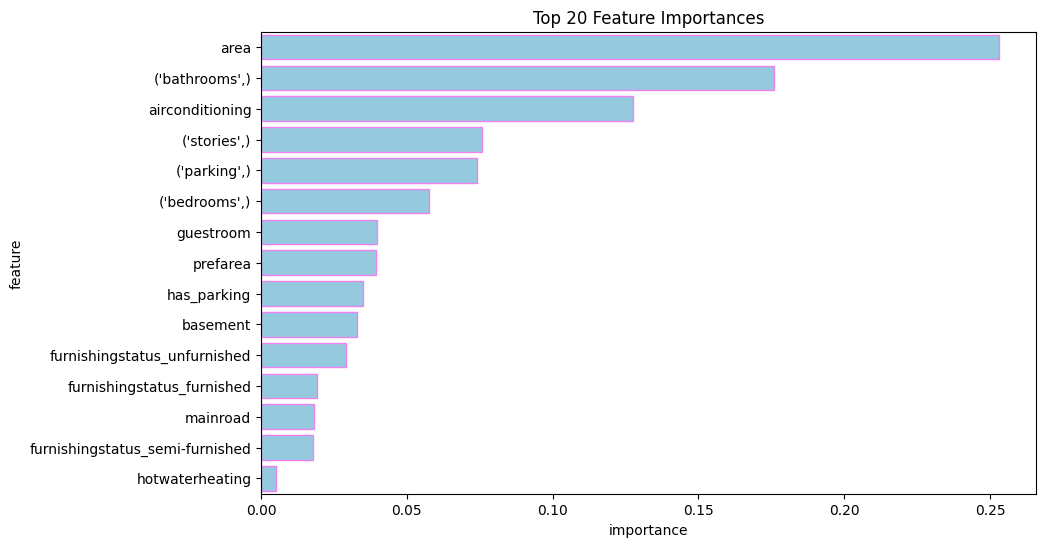

In [56]:
feat_imp = pd.DataFrame({'feature': X_train_final.columns, 'importance': rf1.feature_importances_})
feat_imp = feat_imp.sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(20), color='skyblue', edgecolor='violet')
plt.title('Top 20 Feature Importances')
plt.show()

### XGBoost 

In [53]:
from xgboost import XGBRegressor

from sklearn.model_selection import RandomizedSearchCV

xgb1 = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': np.arange(100, 500, 50),
    'learning_rate': np.linspace(0.01, 0.2, 10),
    'num_leaves': np.arange(16, 64, 8),
    'max_depth': np.arange(3, 10, 1),
    'min_child_samples': np.arange(10, 100, 10),
    'subsample': np.linspace(0.6, 1.0, 5),
    'colsample_bytree': np.linspace(0.6, 1.0, 5),
}

random_search = RandomizedSearchCV(
    estimator=xgb1,
    param_distributions=param_dist,
    n_iter=10,                 
    scoring='roc_auc',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)

print(random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "min_child_samples", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "min_child_samples", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "min_child_samples", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:54:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "min_child_samples", "num_l

{'subsample': 0.9, 'num_leaves': 24, 'n_estimators': 150, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.1788888888888889, 'colsample_bytree': 0.6}


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:54:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "min_child_samples", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [54]:
xg1 = XGBRegressor(random_state=42, subsample=0.9, num_leaves=24, n_estimators=150, min_child_samples=50, max_depth=3, 
                   learning_rate=0.1788888888888889, col_sample_bytree = 0.6
                  )

xg1.fit(X_train_final, y_train)

y_pred_train = xg1.predict(X_train_final)
y_pred_val = xg1.predict(X_test_final)

xg_r2_tr = r2_score(y_train, y_pred_train)
xg_r2_te = r2_score(y_test, y_pred_val)

print("Training r2_score: ", xg_r2_tr)
print("Validation r2_score: ", xg_r2_te)

Training r2_score:  0.9467838406562805
Validation r2_score:  0.6597176790237427


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [13:54:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "col_sample_bytree", "min_child_samples", "num_leaves" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


### Comparable table of metrics for 4 models - Linear Regression, RandomForestRegressor, Lasso, XGBoost

In [55]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Lasso',
        'RandomForestRegressor',
        'XGBoost'
    ],
    'Training R2': [
        lr_r2_tr,
        l_r2_tr,
        rf_r2_tr,
        xg_r2_tr
    ],
    'Validation R2': [
        lr_r2_te,
        l_r2_te,
        rf_r2_te,
        xg_r2_te
    ]
})

results['difference'] = results['Training R2'] - results['Validation R2']
results = results.sort_values(by='Validation R2', ascending=False)

results.style.format({
    'Training R2': '{:.3f}',
    'Validation R2': '{:.3f}',
    'difference': '{:.3f}'
})

,Model,Training R2,Validation R2,difference
0,Linear Regression,0.664,0.666,-0.002
1,Lasso,0.664,0.666,-0.002
3,XGBoost,0.947,0.660,0.287
2,RandomForestRegressor,0.749,0.626,0.123


## Discussion

- The best results are demonstrated by the model Linear Regressor, with val score R2 = 0.66. On cross-validation, the obtained R2 value = 0.62 with std.dev = 0.044. No clear signs of overfitting or undefitting. Lasso achieves quite similar results.

- Other models _RandomForest_, _XGBoost_ with different hyperparameter turning achieve lower results. The value of training R2 score is considerably higher than value of testing R2 score. The XGBoost has a significant difference as well with train R2 score = 0.95 and test R2 score = 0.66. These decision tree models are prone to overfitting with smaller datasets. The current dataset has only 545 rows and 12 columns which is why more complex models are performing poorly compared to simpler models like Lasso and LinearRegression.

- has_parking feature based on RandomForest feature importance: wasn't as informative as original feature parking, so my theory that it doesn't matter how many parking spaces it has isn't confirmed. I also tried to add area per bedroom column, but the values didn't change much, which is why I removed it at the end. 

- Log transformation really helped me with uplifting metrics. It went from 64.6 -> 65.47 when I removed outliers from area and did standardscaler. I applied log transformation only on area because it had highly skewed data while other two features that also hinted on skewed data remained same, only applied scaling method.
When I applied log transformation, the metrics changed 0.659 -> 0.666.

- Feature importance demonstrated the theory the main feature - area, while some features didn't bring almost any value. When I applied log transformation on area, the importance of area increased. Which is why I chose Lasso, to shrink some features and pay more attention to others. The feature importance also demonstrated that the most important features were bathrooms, airconditioning, stories, and etc.

- The best model - _LinearRegression_

- I chose R2 as main metric bsc MAE, MSE were high numbers and to ease the process of interpreting the results, I use that and also to see what percentage from total number of data, the variance of how many the model can explain.

- Example of prediction errors: based on that table, the model has more difficulty with determining the prices of more expensive houses. The higher the price -> the higher the prediction error => model underestimates higher-priced properties. 


### Conclusion 
- In more time availability, I would pay more attention to feature engineering, experiment more - new features out of existing ones
- somehow create how to fill out necessary but absent information - like location or something else 